In [1]:
# import bioframe as bf
import torch
from gpzoo.kernels import batched_RBF
from torch import distributions
import matplotlib.pyplot as plt
from torch import nn, optim
from tqdm.autonotebook import tqdm
from gpzoo.utilities import add_jitter, whitened_KL
from gpzoo.gp import WSVGP
import cooler
from matplotlib.colors import LogNorm
import numpy as np
import cooltools
import pandas as pd
import bioframe as bf
import os, subprocess

/gladstone/engelhardt/home/lchumpitaz/gitclones/GPzoo/gpzoo/utilities.py:2: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
import plotly.graph_objects as go


def plot_3D(Z, X, color=None):
    if color is None:
        color = X.squeeze()
    
    # Define cmin and cmax dynamically
    cmin, cmax = -1.5, 1.5

    fig = go.Figure(data=[go.Scatter3d(
        x=Z[:, 0], 
        y=Z[:, 1], 
        z=Z[:, 2],
        mode='markers',
        marker=dict(
            size=4,
            color=color,  # Coloring based on values
            colorscale='RdBu_r',  # Equivalent to 'bwr'
            cmin=cmin,  # Center around zero
            cmax=cmax,
            colorbar=dict(title="Color Scale")
        )
    )])

    fig.show()

In [3]:
cooler_file = '/gladstone/engelhardt/home/lchumpitaz/gitclones/ChromGP/mcools/4DNFIXP4QG5B.mcool'

In [4]:
resolution = 25000

In [5]:
c = cooler.Cooler(cooler_file+'::resolutions/'+str(resolution))

In [6]:
chroms = ["chr14"]
bins = c.bins()[:]
bins_selected = bins[bins["chrom"].isin(chroms)]

# Get the index ranges for the chromosomes
start_idx = bins_selected.index.min()
end_idx = bins_selected.index.max() + 1  # +1 to include the last bin

In [7]:
if not os.path.isfile('./hg38.fa'):
    ## note downloading a ~1Gb file can take a minute
    subprocess.call('wget --progress=bar:force:noscroll https://hgdownload.cse.ucsc.edu/goldenpath/hg38/bigZips/hg38.fa.gz', shell=True)
    subprocess.call('gunzip hg38.fa.gz', shell=True)

In [8]:
hg38_genome = bf.load_fasta('./hg38.fa');
## note the next command may require installing pysam
gc_cov = bf.frac_gc(bins[['chrom', 'start', 'end']], hg38_genome)
gc_cov.to_csv('hg38_gc_cov_15kb.tsv',index=False,sep='\t')
gc_cov

/gladstone/engelhardt/home/lchumpitaz/gitclones/bioframe/bioframe/extras.py:316: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg = df.groupby("chrom", sort=False)[["start", "end"]].apply(_each)


,chrom,start,end,GC
0,chr1,0,25000,0.573067
1,chr1,25000,50000,0.430960
2,chr1,50000,75000,0.351400
3,chr1,75000,100000,0.402080
4,chr1,100000,125000,0.371200
...,...,...,...,...
123536,chrY,57125000,57150000,0.405240
123537,chrY,57150000,57175000,0.432760
123538,chrY,57175000,57200000,0.506120
123539,chrY,57200000,57225000,0.553775


In [9]:
mat = c.matrix(balance=True)[start_idx:end_idx, start_idx:end_idx]


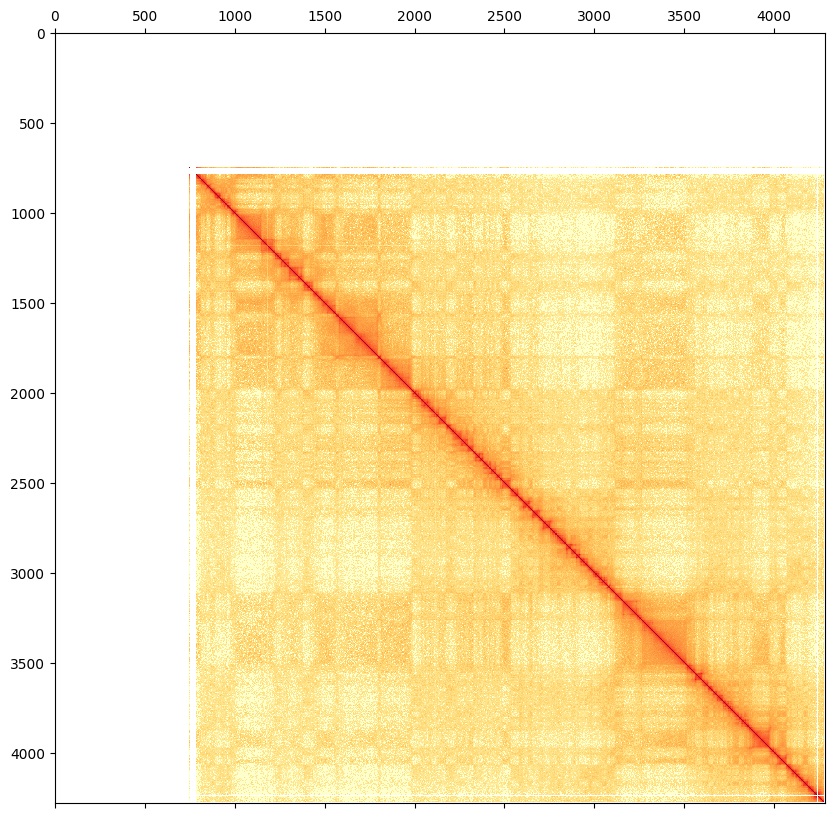

In [10]:
fig, ax = plt.subplots(figsize=(10, 10))
ax.matshow(np.log10(mat + 5e-6),cmap = 'YlOrRd', aspect='equal', interpolation ='none')

In [11]:
target_mat = mat

In [12]:
mask2D = mat==mat

In [13]:
mask1D = mask2D.sum(axis=0)>0
N_masked = sum(mask1D)
N = len(mat.T)

In [14]:
N_masked

3482

In [15]:
mat_masked = mat[mask2D].reshape(-1, N_masked)

In [16]:
# fig, ax = plt.subplots(figsize=(6, 6))
# ax.matshow(np.log10(mat_masked + 5e-6),cmap = 'YlOrRd', aspect='equal', interpolation ='none')

In [17]:
class ChromGP(nn.Module):
    def __init__(self, gp, kernel, noise=0.1, jitter=1e-5):
        super().__init__()
        self.gp = gp
        self.kernel = kernel
        self.jitter = jitter
        self.noise = nn.Parameter(torch.tensor(noise))

    def forward(self, X, E=1, verbose=False, **kwargs):
        N = len(X)
        noise = torch.nn.functional.softplus(self.noise) #ensure positive

        qZ, qU, pU = self.gp(X, verbose=verbose, **kwargs)
        Z = qZ.rsample().T
        Z = torch.squeeze(Z)

        Kzz = kernel.forward(Z, Z)
        Kzz = Kzz.contiguous()
        Kzz = add_jitter(Kzz, self.jitter)
        Kzz.view(-1)[::N+1]+= (noise**2)


        pY = distributions.MultivariateNormal(torch.zeros_like(torch.squeeze(X)), Kzz)

        return pY, qZ, qU, pU

In [18]:
X_full = torch.tensor(bins[bins.chrom=='chr14'].start.values).type(torch.float)/resolution
X = X_full[mask1D]

In [19]:
X

tensor([ 746.,  747.,  766.,  ..., 4273., 4274., 4275.])

In [20]:
view_df = pd.DataFrame({
    "chrom": chroms, 
    "start": [0 for chrom in chroms],  # Start from 0
    "end": [c.chromsizes[chrom] for chrom in chroms]  # End at chromosome length
})
view_df = bf.make_viewframe(view_df)


eigvals, eigvecs = cooltools.eigs_cis(
    
    c, n_eigs=3,  view_df=view_df, phasing_track=gc_cov,# Compute top 3 eigenvectors
)


/gladstone/engelhardt/home/lchumpitaz/miniconda3/envs/chrom/lib/python3.9/site-packages/cooltools/lib/checks.py:550: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for name, group in track.groupby(track.columns[0]):


In [21]:
torch.manual_seed(1226) #3 chroms
# torch.manual_seed(1997) #3 chroms

In [22]:
M = 3000
jitter = 1e-5

# mu = pF.sample((3,)).detach()[:, :M] + 0.1*torch.randn((3,M))

mu = 0.1*torch.randn((3,M))

idx = torch.multinomial(torch.ones(X.shape[0]), num_samples=M, replacement=False)


# mu = (torch.tensor(eigvecs.iloc[mask1D, -3:].values)[idx].T).type(torch.float) #init with eigenvectors
kernel_gp = batched_RBF(sigma=1.0, lengthscale=20.0)
# kernel_gp = batched_RBF(sigma=1.0, lengthscale=1.0)
gp = WSVGP(kernel_gp, M=M, jitter=jitter)

gp.Lu = nn.Parameter(1e-2*torch.eye(M).clone())
gp.Z = nn.Parameter(torch.tensor(X[idx]), requires_grad=False)
# mu = torch.squeeze(torch.stack((torch.torch.sin(torch.pi * gp.Z/10.0), torch.cos(torch.pi * gp.Z/10.0), torch.torch.sin(torch.pi * gp.Z/10.0))))
gp.mu = nn.Parameter(mu)


kernel = batched_RBF(sigma=1.0, lengthscale=1.0)


model = ChromGP(gp, kernel, noise=0.1, jitter=1e-4)



/tmp/ipykernel_4050098/2999903002.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  gp.Z = nn.Parameter(torch.tensor(X[idx]), requires_grad=False)


In [23]:
device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda', index=1)

In [24]:
model.to(device)

ChromGP(
  (gp): WSVGP(
    (kernel): batched_RBF()
  )
  (kernel): batched_RBF()
)

In [25]:
def train(optimizer, model, X, y, device, steps=200, **kwargs):
    Zs = []

    # means = []
    # scales = []
    losses = []
    N = len(X)


    X = X.to(device)
    y = y.to(device)

    
    for it in tqdm(range(steps)):

        optimizer.zero_grad()

        
        pY, qZ, qU, pU = model(X.squeeze())

        y_norm = y- y.mean(dim=1, keepdims=True)
        

        L1 = pY.log_prob(y_norm).sum()
        L2 = torch.sum(torch.vmap(whitened_KL)(qU.mean, qU.scale_tril))

        log_prob = L1 - L2
        loss = -log_prob
        
        
        loss.backward()
        optimizer.step()        
        losses.append(loss.item())
        Zs.append(qZ.mean.T.detach().cpu().clone().numpy())



    X = X.cpu()
    y = y.cpu()
    
    with torch.no_grad():
        if device.type=='cuda':
            torch.cuda.empty_cache()

    return losses, Zs#, means, scales

In [28]:
# model.gp.kernel.lengthscale = nn.Parameter(torch.tensor(86.0*25000))

model.gp.kernel.lengthscale.requires_grad = True
model.gp.kernel.sigma.requires_grad = False
model.kernel.lengthscale.requires_grad = False
model.kernel.sigma.requires_grad = True
model.gp.Lu.requires_grad=False
model.gp.jitter=1e-5
model.jitter=1e-4

optimizer = optim.Adam(model.parameters(), lr=1e-2)

In [29]:
# Y_data = torch.tensor(mat_masked)
Y_data = torch.tensor(np.log10(mat_masked + 5e-6))

In [30]:
model.to(device)
losses, Zs = train(optimizer=optimizer, model=model, X=X, y=Y_data, device=device, steps=1000)

  0%|          | 0/1000 [00:00<?, ?it/s]

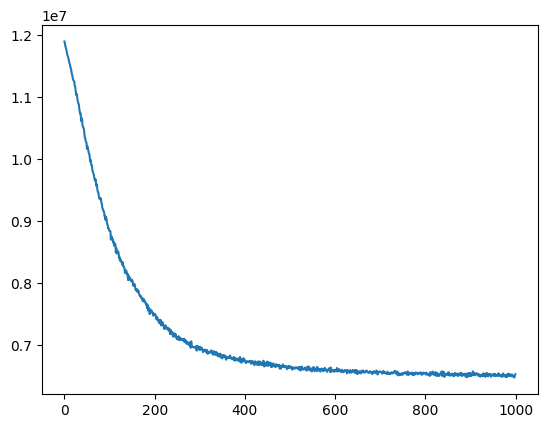

In [31]:
plt.plot(losses)

In [32]:
E1 = eigvecs.E1.values
E1_masked = E1[mask1D]

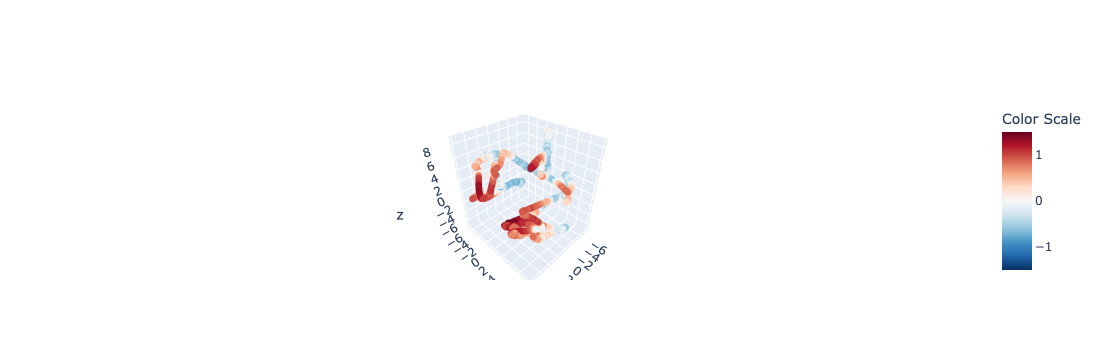

In [34]:
plot_3D(Zs[-1], X, color=-E1_masked)

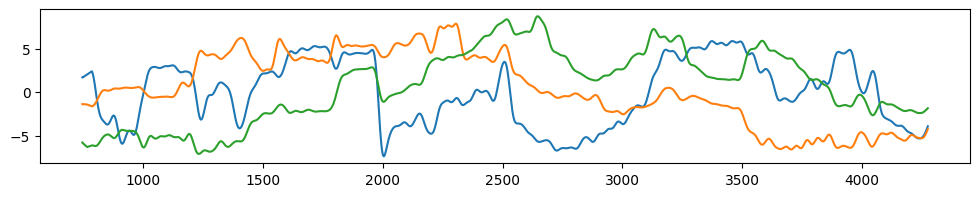

In [35]:
plt.figure(figsize=(12,2))
plt.plot(X, Zs[-1][:,0])
plt.plot(X, Zs[-1][:,1])
plt.plot(X, Zs[-1][:,2])
# plt.plot(X, -E1_masked)"

In [36]:
model.gp.kernel.sigma

Parameter containing:
tensor(1., device='cuda:1')

In [37]:
model.gp.kernel.lengthscale

Parameter containing:
tensor(24.1924, device='cuda:1', requires_grad=True)

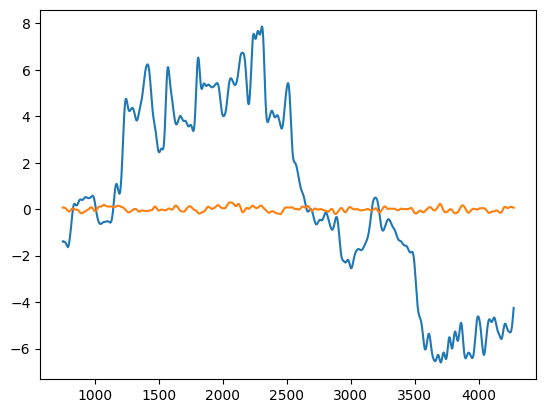

In [38]:
plt.plot(X, Zs[-1][:,1])
plt.plot(X, Zs[0][:,1])
plt.show()

In [39]:
mask2D = mask1D[:, None]@mask1D[None, :]

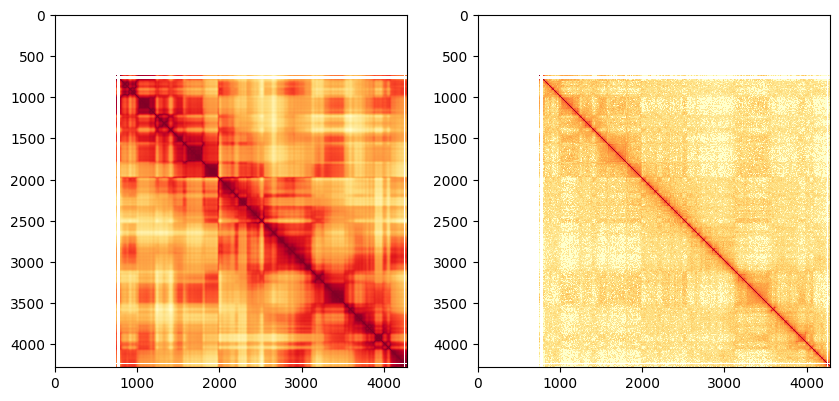

In [40]:
index = -1
reconstructed_dist = np.zeros((N, N))
reconstructed_dist[mask2D] = torch.cdist(torch.tensor(Zs[index]), torch.tensor(Zs[index])).view(-1)
reconstructed_dist[~mask2D] = np.nan
plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.imshow(reconstructed_dist, cmap='YlOrRd_r', aspect='equal', interpolation ='none')
ax = plt.subplot(122)
plt.imshow(np.log10(target_mat + 5e-6),cmap = 'YlOrRd', aspect='equal', interpolation ='none')

In [41]:
model.kernel.sigma

Parameter containing:
tensor(0.3238, device='cuda:1', requires_grad=True)

In [43]:
model.gp.kernel.sigma**2

tensor(1., device='cuda:1')

In [45]:
model.kernel.lengthscale

Parameter containing:
tensor(1., device='cuda:1')

INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
INFO:matplotlib.animation:MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 1200x400 -pix_fmt rgba -framerate 25 -loglevel error -i pipe: -vcodec h264 -pix_fmt yuv420p -y GM12878_WSVGP_chrom14.mp4


hi 0
hi 0
hi 1
hi 2
hi 3
hi 4
hi 5
hi 6
hi 7
hi 8
hi 9
hi 10
hi 11
hi 12
hi 13
hi 14
hi 15
hi 16
hi 17
hi 18
hi 19
hi 20
hi 21
hi 22
hi 23
hi 24
hi 25
hi 26
hi 27
hi 28
hi 29
hi 30
hi 31
hi 32
hi 33
hi 34
hi 35
hi 36
hi 37
hi 38
hi 39
hi 40
hi 41
hi 42
hi 43
hi 44
hi 45
hi 46
hi 47
hi 48
hi 49
hi 50
hi 51
hi 52
hi 53
hi 54
hi 55
hi 56
hi 57
hi 58
hi 59
hi 60
hi 61
hi 62
hi 63
hi 64
hi 65
hi 66
hi 67
hi 68
hi 69
hi 70
hi 71
hi 72
hi 73
hi 74
hi 75
hi 76
hi 77
hi 78
hi 79
hi 80
hi 81
hi 82
hi 83
hi 84
hi 85
hi 86
hi 87
hi 88
hi 89
hi 90
hi 91
hi 92
hi 93
hi 94
hi 95
hi 96
hi 97
hi 98
hi 99
hi 100
hi 101
hi 102
hi 103
hi 104
hi 105
hi 106
hi 107
hi 108
hi 109
hi 110
hi 111
hi 112
hi 113
hi 114
hi 115
hi 116
hi 117
hi 118
hi 119
hi 120
hi 121
hi 122
hi 123
hi 124
hi 0


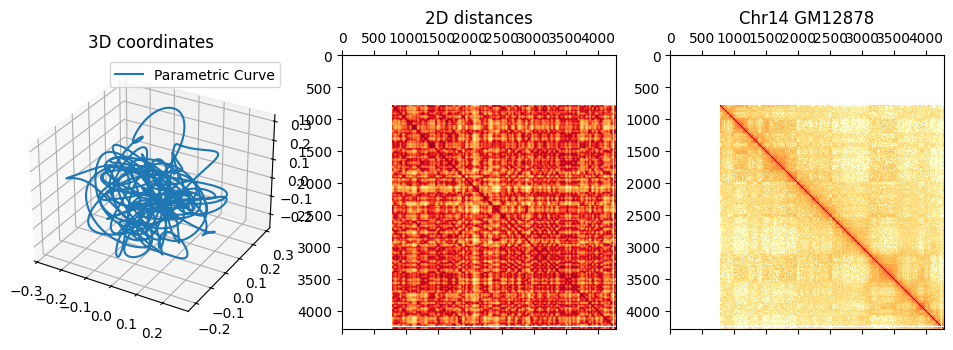

In [48]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import numpy as np


fig = plt.figure(figsize=(12, 4))

ax1 = fig.add_subplot(1, 3, 1, projection='3d')  # 3D plot
ax2 = fig.add_subplot(1, 3, 2)                   # Matshow plot 1
ax3 = fig.add_subplot(1, 3, 3)                   # Matshow plot 2

titles = ["3D coordinates", "2D distances", "Chr14 GM12878"]  # Titles for subplots


mask2D = mask1D[:, None]@mask1D[None, :]
reconstructed_dist = np.zeros((N, N))
reconstructed_dist[~mask2D] = np.nan


def update(iteration):

    
    ax1.cla()   
    curr_Z = Zs[iteration]

    ax1.plot(curr_Z[:, 0], curr_Z[:, 1], curr_Z[:, 2], label='Parametric Curve')
    ax1.legend()
    ax1.set_title(titles[0])

    ax2.cla()
    ax3.cla()
    reconstructed_dist[mask2D] = torch.cdist(torch.tensor(curr_Z), torch.tensor(curr_Z)).view(-1)
    ax2.matshow(reconstructed_dist,cmap = 'YlOrRd_r', aspect='equal', interpolation ='none')
    ax2.set_title(titles[1])
    ax3.matshow(np.log10(target_mat + 5e-6),cmap = 'YlOrRd', aspect='equal', interpolation ='none')
    ax3.set_title(titles[2])

    
    
    print('hi', iteration)


anim = FuncAnimation(fig, update, frames=np.arange(0, 125, 1), interval=100)
# anim = FuncAnimation(fig, update, 
#                      frames= (np.unique(np.logspace(0, np.log10(2500), num=1750, dtype=int))-1), 
#                      interval=100)

# anim.save('pnmf.mp4',
#          writer=animation.FFMpegWriter(fps=50, bitrate=2000, codec='h264'),
#          dpi=50)
anim.save("GM12878_WSVGP_chrom14.mp4", fps=25, dpi=100)

In [77]:
model.cpu()
pY, qZ, qU, pU = model(X_full.squeeze())

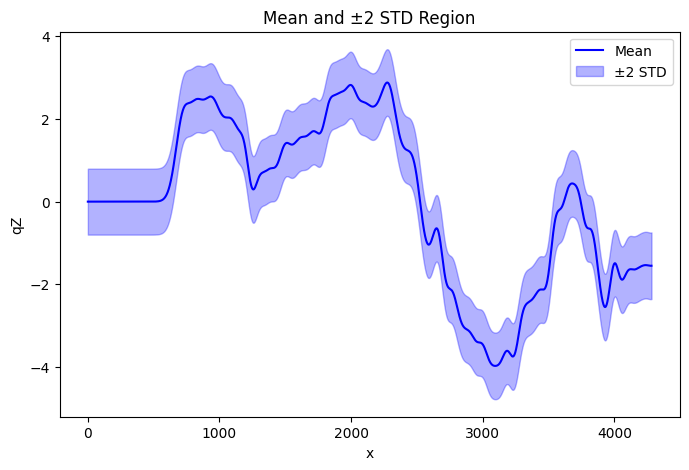

In [78]:

# Extract mean and standard deviation
mean = qZ.mean.detach()
std = qZ.scale.detach()

# Compute upper and lower bounds for the shaded region (±2 stds)
upper = mean + 2.0 * std
lower = mean - 2.0 * std

# Plot
plt.figure(figsize=(8, 5))
plt.plot(X_full, mean[0], label="Mean", color="blue")
plt.fill_between(X_full.squeeze(), lower[0].numpy(), upper[0].numpy(), color="blue", alpha=0.3, label="±2 STD")
plt.xlabel("x")
plt.ylabel("qZ")
plt.legend()
plt.title("Mean and ±2 STD Region")
plt.show()

In [43]:
std

tensor([[1.0000, 1.0000, 1.0000,  ..., 0.0447, 0.0546, 0.0662],
        [1.0000, 1.0000, 1.0000,  ..., 0.0447, 0.0546, 0.0662],
        [1.0000, 1.0000, 1.0000,  ..., 0.0447, 0.0546, 0.0662]])